In [13]:
import numpy as np
import pandas as pd 
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as pm
%matplotlib inline
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scipy.stats as stats
import warnings
from sklearn.linear_model import LinearRegression
warnings.filterwarnings('ignore')
import re


In [14]:
apt_data = pd.read_csv('/kaggle/input/datasets/micahluftig/apt-and-p-data/apt_data.csv')
p_data = pd.read_csv('/kaggle/input/datasets/micahluftig/apt-and-p-data/p_data.csv')

In [15]:
print(p_data.head())
print(p_data.columns)

  animal_id  age_at_first_visit spp    akc_group         outcome_time sex_out  \
0   a006100                10.0  k9     sporting                  NaN     NaN   
1   a047759                10.0  k9        hound  2014-04-07 15:12:00       n   
2   a134067                16.0  k9      herding  2013-11-16 11:54:00       n   
3   a141142                15.0  k9  mixed_breed  2013-11-17 11:40:00       s   
4   a163459                15.0  k9      terrier  2014-11-14 19:28:00       f   

   pregnant_o_nursing  
0                   0  
1                   0  
2                   0  
3                   0  
4                   0  
Index(['animal_id', 'age_at_first_visit', 'spp', 'akc_group', 'outcome_time',
       'sex_out', 'pregnant_o_nursing'],
      dtype='object')


In [16]:
conn = sqlite3.connect('shelter_data.db')

try:
    # Create tables if they do not already exist
    apt_data.to_sql('apt_data', conn, index=False, if_exists='replace')
    p_data.to_sql('p_data', conn, index=False, if_exists='replace')
    

    print('Database tables created successfully.')

except ValueError:
    print('Tables already exist. Skipping creation step.')

# ---------------------------------------------------
# RECIDIVISM ANALYSIS
# Measures time between repeat intakes
# ---------------------------------------------------

query = """
WITH return_matches AS (
  SELECT
    A.animal_id,
    P.spp,
    P.akc_group,
    A.intake_id AS first_apt,
    A.intake_time AS first_intake_time,
    A.discharge_time AS first_discharge_time,
    A.intake_reason AS first_reason,
    A.los_days AS los_days,
    B.intake_id AS return_apt,
    B.intake_time AS return_intake_time,
    B.intake_reason AS return_reason,
    P.age_at_first_visit AS age_at_first_visit,
    ROW_NUMBER() OVER (
      PARTITION BY A.intake_id
      ORDER BY B.intake_time
    ) AS rn
  FROM apt_data A
  JOIN apt_data B
    ON A.animal_id = B.animal_id
   AND B.intake_time > A.discharge_time
  JOIN p_data P
    ON P.animal_id = A.animal_id
  WHERE julianday(B.intake_time) - julianday(A.discharge_time) <= 30
    AND julianday(B.intake_time) - julianday(A.discharge_time) > 0
)

SELECT
  animal_id,
  spp,
  akc_group,
  first_intake_time,
  first_discharge_time,
  return_intake_time,
  first_reason,
  return_reason,
  los_days,
  CASE
    WHEN los_days <= 1.9 THEN '0-1'
    WHEN los_days <= 7.9 THEN '2-7'
    WHEN los_days <= 30.9 THEN '8-30'
    WHEN los_days <= 90.9 THEN '31-90'
    ELSE '90+ Days'
  END AS los_cat_days,
  age_at_first_visit,
  ROUND(julianday(return_intake_time) - julianday(first_discharge_time), 2) AS return_time_days
FROM return_matches
WHERE rn = 1
ORDER BY animal_id, first_intake_time;
"""

# Run query
recidivism_result = pd.read_sql_query(query, conn)

# Display results
print(recidivism_result)

# Close connection
conn.close()


date_cols = ['first_intake_time', 'first_discharge_time', 'return_intake_time']

recidivism_result[date_cols] = recidivism_result[date_cols].apply(lambda col: pd.to_datetime(col))

Database tables created successfully.
     animal_id spp    akc_group    first_intake_time first_discharge_time  \
0      a337686  k9      herding  2015-05-28 17:51:00  2015-05-29 18:43:00   
1      a345209  k9     sporting  2014-11-23 13:00:00  2014-11-26 14:11:00   
2      a355753  k9        hound  2015-09-10 13:14:00  2015-09-19 18:08:00   
3      a362383  k9      terrier  2016-03-11 11:50:00  2016-03-22 17:53:00   
4      a378348  k9      herding  2013-12-12 11:07:00  2014-01-19 13:39:00   
...        ...  ..          ...                  ...                  ...   
4911   a828751  k9      herding  2021-01-25 17:49:00  2021-01-30 11:33:00   
4912   a828781  k9      herding  2021-01-26 08:52:00  2021-01-27 17:40:00   
4913   a828826  k9      terrier  2021-01-26 17:47:00  2021-02-01 17:55:00   
4914   a828891  k9  mixed_breed  2021-01-28 10:55:00  2021-02-02 17:58:00   
4915   a829148  k9      terrier  2021-02-03 09:40:00  2021-02-08 16:07:00   

       return_intake_time first_reaso

In [17]:
def table_check(df, df_name, unique_id) -> pd.DataFrame:
    print(f'Beginning errorcheck for: {df_name} ***')
    print(f'\n--- Null Value Check ---')
    for column in df.columns: 
        null_count = df[column].isna().sum() 
        print(f'{column} nulls: {null_count}')
    print('\n')
    
    print(f'--- Integrity Check ---')
    if unique_id in df.columns:
        duplicate_count = df[unique_id].duplicated().sum()
        print(f'Total {unique_id} duplicates: {duplicate_count}')
    else:
        print(f"WARNING: {unique_id} not found for duplication check.")
    print('\n')
    print(f'\n--- Data Type Audit (DF.dtypes) ---')
    print(df.dtypes)
    
    print(f'\n--- Numerical Sanity Check (DF.describe) ---')
    
    numeric_cols = df.select_dtypes(include = ['int64', 'float64', 'Int64', 'int32']).columns
    if not numeric_cols.empty:
        print(df[numeric_cols].describe())
    else:
        print('No standard numerical columns found for description.')

    print(f'\n--- Categorical Value Audit (Top 10 Counts) ---')
    object_cols = df.select_dtypes(include=['object', 'string[python]']).columns

    for column in object_cols:
        print(f'\n{column.upper()}:')
        print(df[column].value_counts().nlargest(10))

    

    print('\n\n\n')

    return df

In [18]:
x = table_check(recidivism_result, 'recidivism_result', 'animal_id')

Beginning errorcheck for: recidivism_result ***

--- Null Value Check ---
animal_id nulls: 0
spp nulls: 0
akc_group nulls: 911
first_intake_time nulls: 0
first_discharge_time nulls: 0
return_intake_time nulls: 0
first_reason nulls: 0
return_reason nulls: 0
los_days nulls: 0
los_cat_days nulls: 0
age_at_first_visit nulls: 0
return_time_days nulls: 0


--- Integrity Check ---
Total animal_id duplicates: 653



--- Data Type Audit (DF.dtypes) ---
animal_id                       object
spp                             object
akc_group                       object
first_intake_time       datetime64[ns]
first_discharge_time    datetime64[ns]
return_intake_time      datetime64[ns]
first_reason                    object
return_reason                   object
los_days                       float64
los_cat_days                    object
age_at_first_visit             float64
return_time_days               float64
dtype: object

--- Numerical Sanity Check (DF.describe) ---
          los_days  age_

In [19]:
def normality_test(df, y_axis, x_axis):
    
    df_clean = df.dropna(subset=[y_axis, x_axis]).copy()
    
    transformations = {
        f'Regular ({y_axis})': df_clean[y_axis],
        f'Log (log({y_axis} + 0.001))': np.log(df_clean[y_axis] + 0.001),
        f'Sqrt (sqrt({y_axis}))': np.sqrt(df_clean[y_axis]),
        f'Log-Sqrt (log(sqrt({y_axis}) + 0.001))': np.log(np.sqrt(df_clean[y_axis]) + 0.001)
    }
    
    print('=' * 50)
    print(f'{y_axis} by {x_axis}\n\n')
    
    
    for label, y_values in transformations.items():
        
        df_clean['temp_y'] = y_values
        residuals = smf.ols(f'temp_y ~ {x_axis}', data=df_clean).fit().resid
        stat, p_val = stats.shapiro(residuals)
        
        
        print(f'{label}')
        print(f'Transformation: {label}')
        print(f'  W = {stat:.5f}, p-value = {p_val:.5e}\n')
        
    print('=' * 50)
    return df

# normality_test(
#     df = recidivism_result,
#     y_axis = 'return_time_days',
#     x_axis = 'first_reason'
# )

def normality_plot(df, y_axis):
    epsilon = 0.001
    y_clean = df[y_axis].dropna()
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    
    
    transformations = [
        ('regular', y_clean),
        ('sqrt', np.sqrt(y_clean)),
        ('log', np.log(y_clean + epsilon)),
        ('log(sqrt)', np.log(np.sqrt(y_clean) + epsilon))
    ]
    
   
    for (title, y_values), ax in zip(transformations, axes.flat):
        stats.probplot(y_values, plot=ax)
        ax.set_title(f'Normal Q-Q: {title}')
    plt.tight_layout()
    plt.show()
    
    return df

def kruskal_wallis(df, y_axis, x_axis):
    # 1. Gather the data groups in one clean line
    groups = [group[y_axis] for name, group in df.groupby(x_axis, observed = False)]
    
    # 2. Run the test
    stat, p_val = stats.kruskal(*groups)
    
    # 3. Print the results
    print('=' * 50)
    print(f'Kruskal-Wallis rank sum test')
    print(f'Data: {y_axis} by {x_axis}')
    print(f'  Chi-squared = {stat:.5f}, p-value = {p_val:.5e}')
    print('=' * 50)
    
    return df


def behavior_v_return_time(df, y_axis, x_axis) -> pd.DataFrame:
    return (df
            .pipe(normality_test, y_axis, x_axis)
            .pipe(normality_plot, y_axis)
            .pipe(kruskal_wallis, y_axis, x_axis)
    )

return_time_days by first_reason


Regular (return_time_days)
Transformation: Regular (return_time_days)
  W = 0.87605, p-value = 1.41844e-52

Log (log(return_time_days + 0.001))
Transformation: Log (log(return_time_days + 0.001))
  W = 0.91674, p-value = 6.94153e-46

Sqrt (sqrt(return_time_days))
Transformation: Sqrt (sqrt(return_time_days))
  W = 0.95623, p-value = 4.52025e-36

Log-Sqrt (log(sqrt(return_time_days) + 0.001))
Transformation: Log-Sqrt (log(sqrt(return_time_days) + 0.001))
  W = 0.85519, p-value = 2.56389e-55



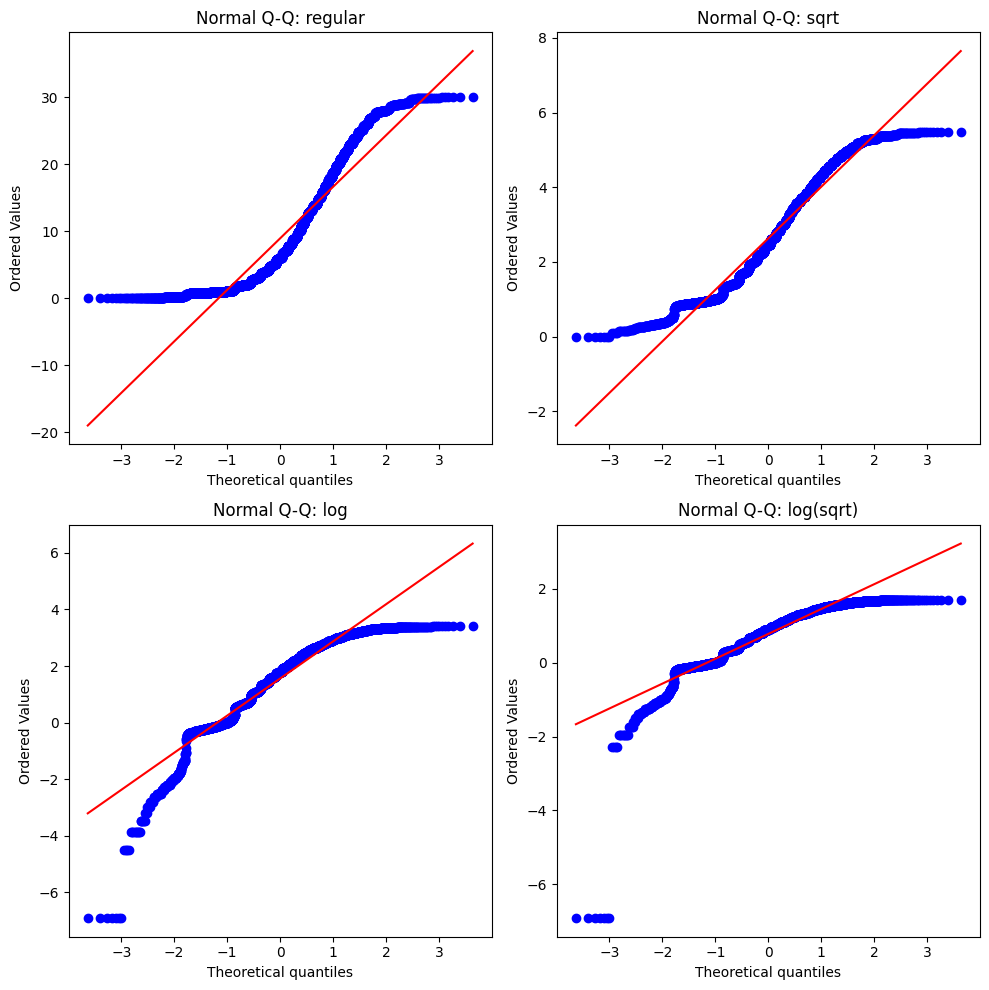

Kruskal-Wallis rank sum test
Data: return_time_days by first_reason
  Chi-squared = 3.31967, p-value = 3.44914e-01


In [20]:
behavior_v_return_time_output = behavior_v_return_time(recidivism_result, 'return_time_days', 'first_reason')

In [21]:
# Regression analysis: predict return_time_days from LOS, age, species, and intake reason
regression_df = recidivism_result.copy()
regression_df = regression_df.dropna(subset=['return_time_days', 'los_days', 'age_at_first_visit', 'first_reason', 'spp']).copy()
regression_df = regression_df[regression_df['return_time_days'] > 0]  # only positive return times
regression_df['first_reason'] = regression_df['first_reason'].astype(str).str.strip()
regression_df['spp'] = regression_df['spp'].astype(str).str.strip()
regression_df = pd.get_dummies(regression_df, columns=['first_reason', 'spp'], drop_first=True)
predictors = ['los_days', 'age_at_first_visit'] + [col for col in regression_df.columns if col.startswith('first_reason_') or col.startswith('spp_')]
formula = 'return_time_days ~ ' + ' + '.join(predictors)
model = smf.ols(formula=formula, data=regression_df).fit()
print('\nRegression formula:')
print(formula)
print('\nRegression summary:')
print(model.summary())



Regression formula:
return_time_days ~ los_days + age_at_first_visit + first_reason_medical + first_reason_other + first_reason_routine + spp_k9 + spp_other + spp_wildlife

Regression summary:
                            OLS Regression Results                            
Dep. Variable:       return_time_days   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.246
Date:                Mon, 22 Jun 2026   Prob (F-statistic):              0.268
Time:                        17:17:50   Log-Likelihood:                -17302.
No. Observations:                4909   AIC:                         3.462e+04
Df Residuals:                    4900   BIC:                         3.468e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                

In [22]:
import pandas as pd
import statsmodels.formula.api as smf

# 1. Print the raw category counts so you can see the distribution
print("--- Category Distribution ---")
print(recidivism_result['first_reason'].value_counts())
print("\n" + "="*50 + "\n")

# 2. Create a clean binary feature (1 if medical, 0 if routine or other)
recidivism_result['is_medical'] = (recidivism_result['first_reason'] == 'medical').astype(float)

# 3. Fit the updated OLS model using our new binary column
# Note: We completely remove C(first_reason) to stop the severe multicollinearity
updated_model = smf.ols(
    formula='return_time_days ~ age_at_first_visit + los_days + is_medical', 
    data=recidivism_result
).fit()

# 4. View the new results
print("--- Updated Model Summary ---")
print(updated_model.summary())


--- Category Distribution ---
first_reason
routine     4676
medical      232
other          6
behavior       2
Name: count, dtype: int64


--- Updated Model Summary ---
                            OLS Regression Results                            
Dep. Variable:       return_time_days   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.752
Date:                Mon, 22 Jun 2026   Prob (F-statistic):              0.154
Time:                        17:17:53   Log-Likelihood:                -17330.
No. Observations:                4916   AIC:                         3.467e+04
Df Residuals:                    4912   BIC:                         3.469e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err 

In [23]:
# Create the binary target variable: 
# 1 if the animal returned within a week, 0 if it took longer than a week
recidivism_result['is_rapid_return'] = (recidivism_result['return_time_days'] <= 7.9).astype(int)

# Quick sanity check to see your new class balance
print(recidivism_result['is_rapid_return'].value_counts())

is_rapid_return
1    2814
0    2102
Name: count, dtype: int64


In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Select the features you want to use to predict the return
feature_cols = ['spp', 'akc_group', 'first_reason', 'los_days', 'age_at_first_visit']

# 2. Separate your inputs (X) and your new target variable (y)
X = recidivism_result[feature_cols]
y = recidivism_result['is_rapid_return']

# 3. Convert text categories into numerical "dummy" columns (One-Hot Encoding)
# This turns 'spp_k9' into 1s and 0s automatically!
X = pd.get_dummies(X, drop_first=True)

# 4. Split your data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
from sklearn.ensemble import RandomForestClassifier

# You must define and fit the model before you can look at features
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)


RandomForestClassifier()

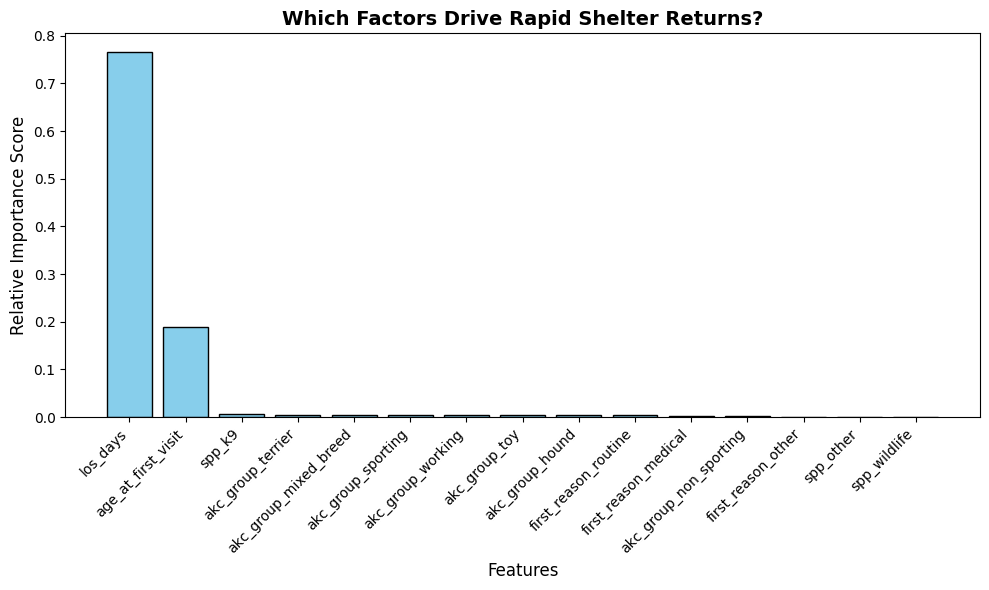

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Extract feature importances from your trained model
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# 2. Plot the results
plt.figure(figsize=(10, 6))
plt.title("Which Factors Drive Rapid Shelter Returns?", fontsize=14, fontweight='bold')
plt.bar(range(X.shape[1]), importances[indices], color='skyblue', align="center", edgecolor='black')
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=45, ha='right', fontsize=10)
plt.ylabel("Relative Importance Score", fontsize=12)
plt.xlabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

In [27]:
# Calculate the actual percentage of rapid returns for different lengths of stay
recidivism_result['los_weeks'] = (recidivism_result['los_days'] / 7).round()
tipping_point = recidivism_result.groupby('los_weeks')['is_rapid_return'].mean()
print(tipping_point)

los_weeks
0.0      0.483784
1.0      0.603702
2.0      0.592251
3.0      0.600733
4.0      0.567308
5.0      0.664740
6.0      0.570552
7.0      0.647619
8.0      0.518987
9.0      0.611940
10.0     0.632653
11.0     0.688889
12.0     0.656250
13.0     0.560976
14.0     0.714286
15.0     0.526316
16.0     0.550000
17.0     0.312500
18.0     0.750000
19.0     0.714286
20.0     0.800000
21.0     0.400000
22.0     0.600000
23.0     0.750000
24.0     0.666667
25.0     0.500000
26.0     0.400000
27.0     0.428571
28.0     0.666667
29.0     0.333333
32.0     1.000000
33.0     0.285714
34.0     0.000000
35.0     0.500000
36.0     0.500000
39.0     0.000000
40.0     0.333333
41.0     0.000000
43.0     0.250000
45.0     0.000000
49.0     0.000000
50.0     1.000000
52.0     0.000000
58.0     1.000000
60.0     1.000000
62.0     0.000000
73.0     0.000000
76.0     0.000000
79.0     1.000000
121.0    0.000000
Name: is_rapid_return, dtype: float64


In [28]:
# Look at both the mean risk AND the total count of animals per week
tipping_point_summary = recidivism_result.groupby('los_weeks')['is_rapid_return'].agg(['mean', 'count'])
print(tipping_point_summary.head(15))

               mean  count
los_weeks                 
0.0        0.483784   1110
1.0        0.603702   1837
2.0        0.592251    542
3.0        0.600733    273
4.0        0.567308    208
5.0        0.664740    173
6.0        0.570552    163
7.0        0.647619    105
8.0        0.518987     79
9.0        0.611940     67
10.0       0.632653     49
11.0       0.688889     45
12.0       0.656250     32
13.0       0.560976     41
14.0       0.714286     28


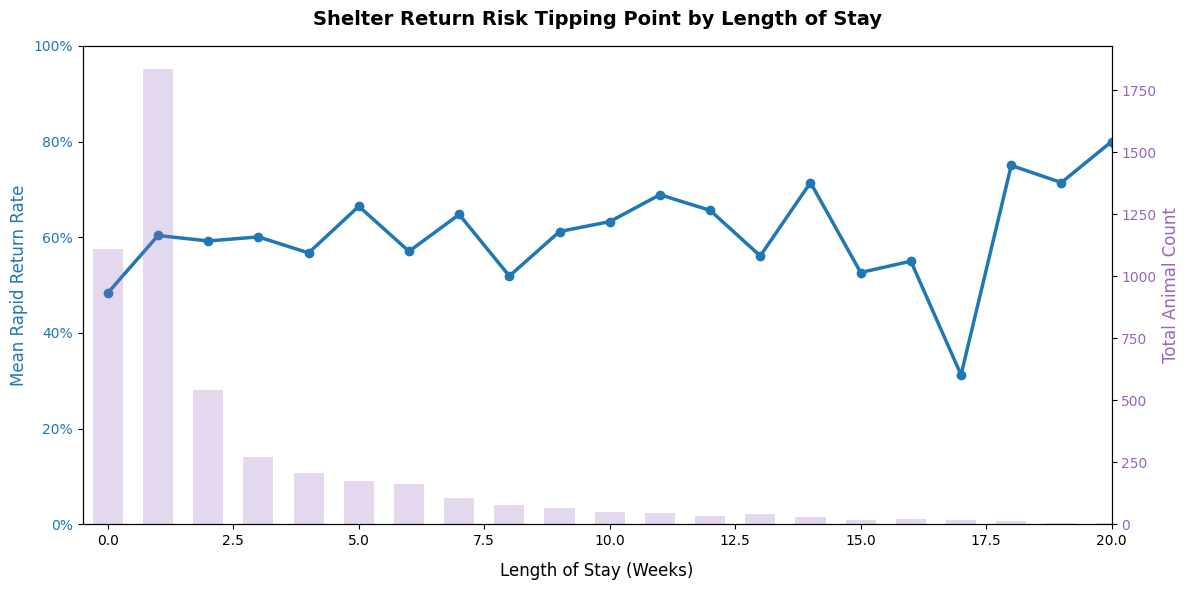

In [29]:
import matplotlib.pyplot as plt

# Set up the figure and the first axis (for the line chart)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the rapid return rate as a line chart
color = '#1f77b4'
ax1.set_xlabel('Length of Stay (Weeks)', fontsize=12, labelpad=10)
ax1.set_ylabel('Mean Rapid Return Rate', color=color, fontsize=12)
line = ax1.plot(tipping_point_summary.index, tipping_point_summary['mean'], 
                color=color, marker='o', linewidth=2.5, label='Return Rate')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 1)

# Format the y-axis as percentages for professional readability
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Set up a second axis that shares the same x-axis (for the volume bars)
ax2 = ax1.twinx()  
color = '#9467bd'
ax2.set_ylabel('Total Animal Count', color=color, fontsize=12)
bars = ax2.bar(tipping_point_summary.index, tipping_point_summary['count'], 
               color=color, alpha=0.25, width=0.6, label='Animal Volume')
ax2.tick_params(axis='y', labelcolor=color)

# Clean up layout and add titles
plt.title('Shelter Return Risk Tipping Point by Length of Stay', fontsize=14, pad=15, fontweight='bold')
fig.tight_layout()

# Save the visualization directly to your portfolio folder
plt.savefig('return_risk_tipping_point.png', dpi=300)
# Cut off the chart at 20 weeks to eliminate low-volume sample noise
ax1.set_xlim(-0.5, 20)

plt.show()


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.48      0.47      0.47       427
           1       0.60      0.61      0.60       557

    accuracy                           0.55       984
   macro avg       0.54      0.54      0.54       984
weighted avg       0.55      0.55      0.55       984

--- Confusion Matrix ---


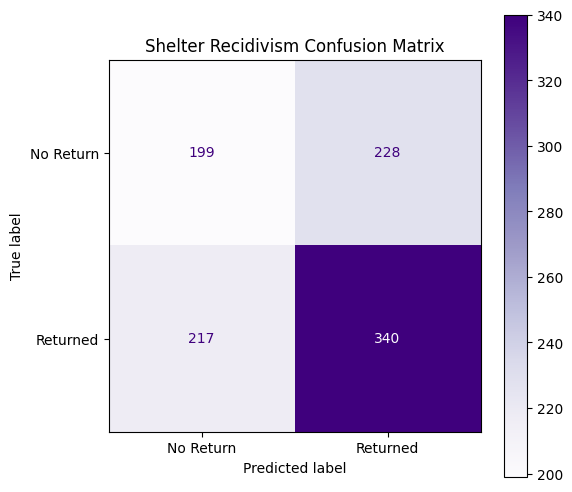

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Generate predictions using your trained model and test data
# (Note: Replace 'rf_model' and 'X_test', 'y_test' with your actual variable names)
y_pred = rf_model.predict(X_test)

# 2. Print Precision, Recall, and F1-Score
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 3. Create and plot a Confusion Matrix
print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Return', 'Returned'])

# Plotting the matrix nicely
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Purples', ax=ax)
plt.title("Shelter Recidivism Confusion Matrix")
plt.show()


In [31]:
!pip freeze > requirements.txt